In [61]:

import numpy as np
import torch
import torch.nn as nn

import matplotlib.pyplot as plt


In [62]:

def compute_z(a, b, c):
    r1 = torch.sub(a, b)
    r2 = torch.mul(r1, 2)
    z = torch.add(r2, c)
    return z


In [63]:

compute_z( torch.tensor(3), torch.tensor(2), torch.tensor(1) )


tensor(3)

In [64]:

a = torch.tensor(3.14, requires_grad=True)
a


tensor(3.1400, requires_grad=True)

In [65]:

b = torch.tensor([1.0, 2.0, 3.0], requires_grad=True)
b


tensor([1., 2., 3.], requires_grad=True)

In [66]:

torch.manual_seed(1)
w = torch.empty(2, 3)
w


tensor([[9.5631e-17, 0.0000e+00, 0.0000e+00],
        [0.0000e+00, 1.1210e-43, 0.0000e+00]])

In [67]:

nn.init.xavier_normal_(w)
w


tensor([[ 0.4183,  0.1688,  0.0390],
        [ 0.3930, -0.2858, -0.1051]])

In [68]:

class MyModule(nn.Module):
    def __init__(self):
        super().__init__()

        self.w1 = torch.empty((2, 3), requires_grad=True)
        nn.init.xavier_normal_(self.w1)

        self.w2 = torch.empty((1, 2), requires_grad=True)
        nn.init.xavier_normal_(self.w2)


In [69]:

w = torch.tensor(1.0, requires_grad=True)
w


tensor(1., requires_grad=True)

In [70]:

b = torch.tensor(0.5, requires_grad=True)
b


tensor(0.5000, requires_grad=True)

In [71]:

x = torch.tensor([1.4])
x


tensor([1.4000])

In [72]:

y = torch.tensor(2.1)
y


tensor(2.1000)

In [73]:

z = torch.add(  torch.mul(w, x), b  )
z


tensor([1.9000], grad_fn=<AddBackward0>)

In [74]:

loss = (y-z).pow(2).sum()
loss


tensor(0.0400, grad_fn=<SumBackward0>)

In [75]:

loss.backward()
loss


tensor(0.0400, grad_fn=<SumBackward0>)

In [76]:

print("dL/dw: ", w.grad)
print("dL/db: ", b.grad)


dL/dw:  tensor(-0.5600)
dL/db:  tensor(-0.4000)


In [77]:

## verify computed gradient

dL_dw = 2*x*((w*x+b) - y)

print(dL_dw)


tensor([-0.5600], grad_fn=<MulBackward0>)


In [78]:

model = nn.Sequential(
              nn.Linear(4, 16),
              nn.ReLU(),
              nn.Linear(16, 32),
              nn.ReLU()
)

model


Sequential(
  (0): Linear(in_features=4, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=32, bias=True)
  (3): ReLU()
)

In [79]:

np.random.seed(1)

X = np.random.uniform(  low=-1, high=1, size=(200, 2)   )

X.shape


(200, 2)

In [80]:

X


array([[-1.65955991e-01,  4.40648987e-01],
       [-9.99771250e-01, -3.95334855e-01],
       [-7.06488218e-01, -8.15322810e-01],
       [-6.27479577e-01, -3.08878546e-01],
       [-2.06465052e-01,  7.76334680e-02],
       [-1.61610971e-01,  3.70439001e-01],
       [-5.91095501e-01,  7.56234873e-01],
       [-9.45224814e-01,  3.40935020e-01],
       [-1.65390395e-01,  1.17379657e-01],
       [-7.19226123e-01, -6.03797022e-01],
       [ 6.01489137e-01,  9.36523151e-01],
       [-3.73151644e-01,  3.84645231e-01],
       [ 7.52778305e-01,  7.89213327e-01],
       [-8.29911577e-01, -9.21890434e-01],
       [-6.60339161e-01,  7.56285007e-01],
       [-8.03306332e-01, -1.57784750e-01],
       [ 9.15779060e-01,  6.63305699e-02],
       [ 3.83754228e-01, -3.68968738e-01],
       [ 3.73001855e-01,  6.69251344e-01],
       [-9.63423445e-01,  5.00288630e-01],
       [ 9.77722178e-01,  4.96331309e-01],
       [-4.39112016e-01,  5.78558657e-01],
       [-7.93547987e-01, -1.04212948e-01],
       [ 8.

In [81]:

y = np.ones(   len(X)    )

y


array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [82]:

## XOR data

y[  X[:, 0] * X[:, 1] < 0   ] = 0


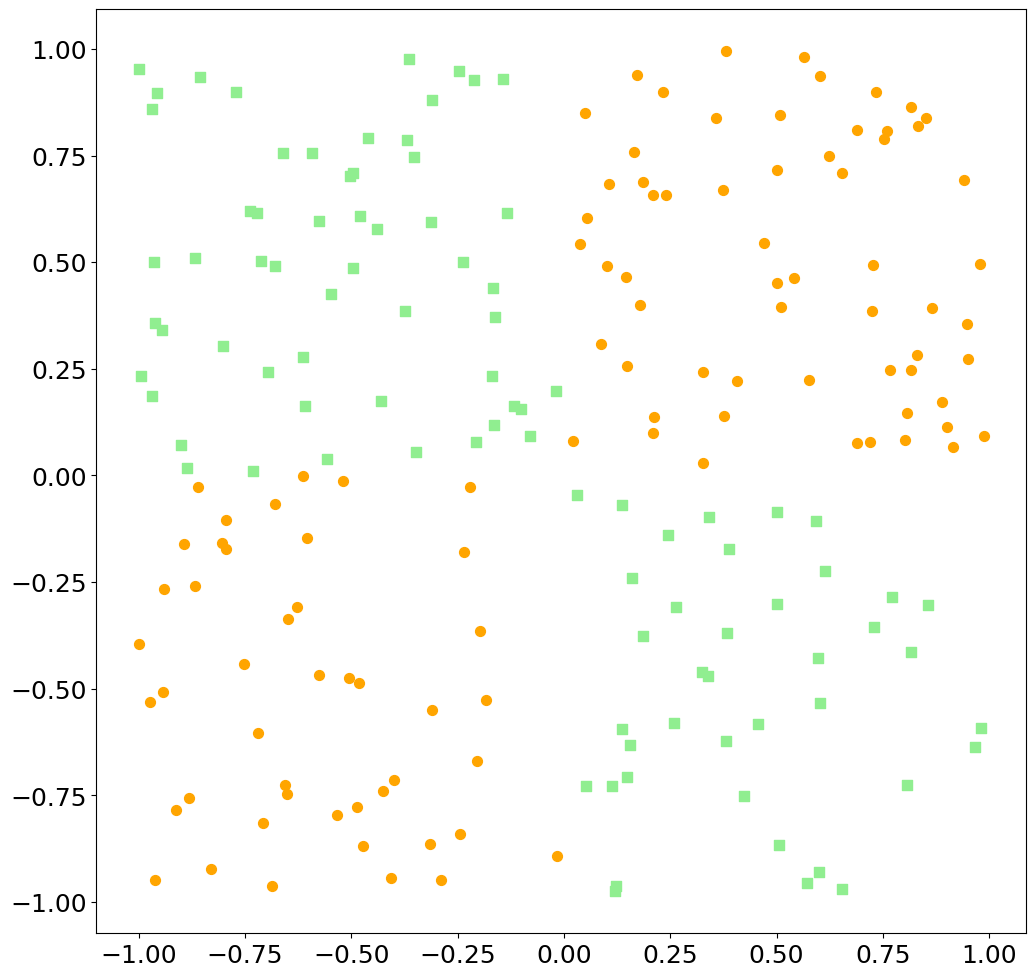

In [83]:

## plt.scatter(X[:, 0], X[:, 1] )


plt.scatter(X[y==0,0],
            X[y==0,1],
            s=50,
            c='lightgreen',
            marker='s',
            label='class0')
plt.scatter(X[y==1,0],
            X[y==1,1],
            s=50,
            c='orange',
            marker='o',
            label='class1')
plt.show()


In [84]:

X_train = X[:100, :]
y_train = y[:100]

X_test  = X[100:, :]
y_test  = y[100:]


In [86]:

# =========================
# XOR: Logistic vs Neural Net (PyTorch)
# =========================

import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt



In [88]:

# =========================
# DATA (XOR)
# =========================
N = 200

X = torch.randn(N, 2)
y = torch.zeros(N)

# XOR condition
y[X[:, 0] * X[:, 1] < 0] = 1  # class 1 if signs differ

y = y.view(-1, 1)


In [89]:

# =========================
# MODELS
# =========================

# Logistic Regression (linear)
class LogisticModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(2, 1)

    def forward(self, x):
        return torch.sigmoid(self.linear(x))


In [90]:

# Simple Neural Network (nonlinear)
class SimpleNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 8),
            nn.ReLU(),
            nn.Linear(8, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)


In [91]:


# =========================
# TRAIN FUNCTION
# =========================
def train(model, X, y, epochs=1000):
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.01)

    for _ in range(epochs):
        optimizer.zero_grad()
        y_pred = model(X)
        loss = criterion(y_pred, y)
        loss.backward()
        optimizer.step()

    return model


In [92]:

# =========================
# EVALUATION (F1)
# =========================
def evaluate(model, X, y):
    with torch.no_grad():
        preds = model(X)
        preds = (preds > 0.5).float()
        f1 = f1_score(y.numpy(), preds.numpy())
    return f1



In [93]:




# =========================
# TRAIN BOTH MODELS
# =========================
log_model = LogisticModel()
nn_model  = SimpleNN()

train(log_model, X, y)
train(nn_model, X, y)

f1_log = evaluate(log_model, X, y)
f1_nn  = evaluate(nn_model, X, y)

print("Logistic Regression F1:", f1_log)
print("Neural Network F1:", f1_nn)


Logistic Regression F1: 0.5726495726495726
Neural Network F1: 0.995260663507109


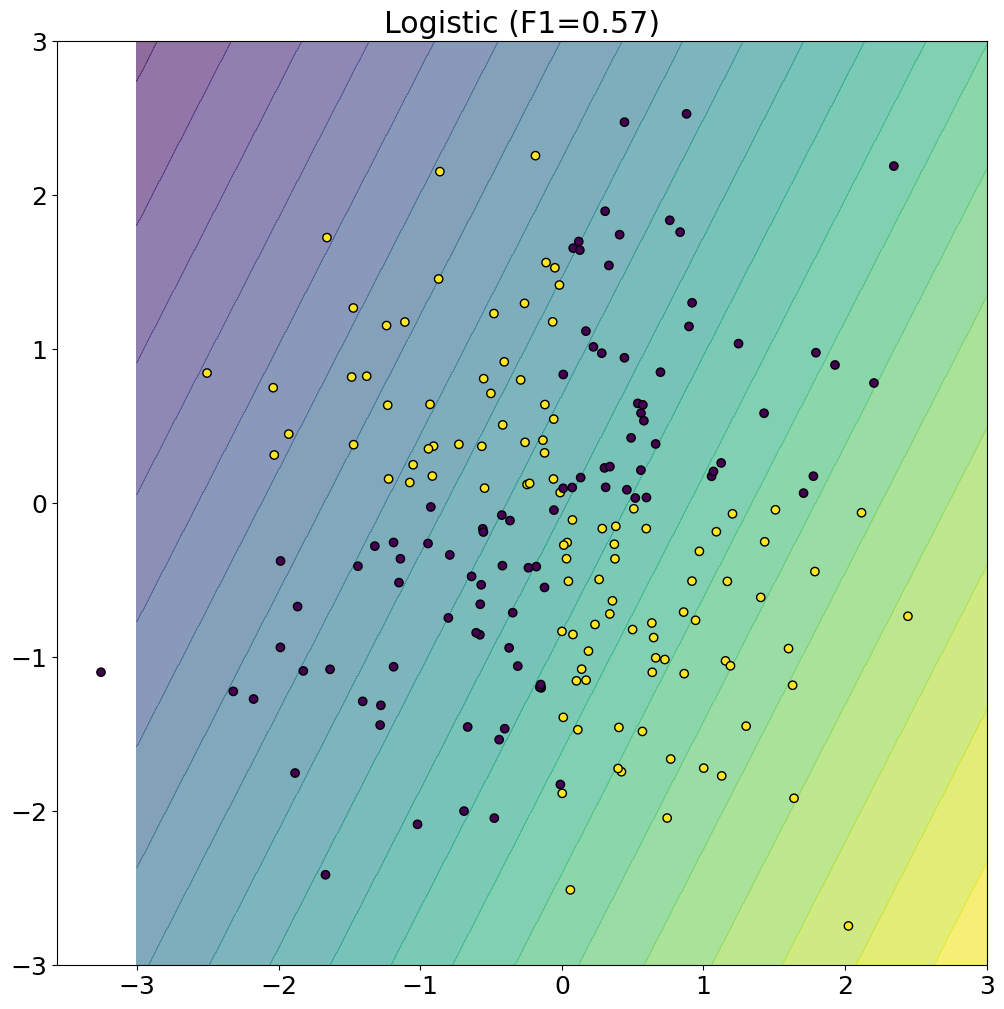

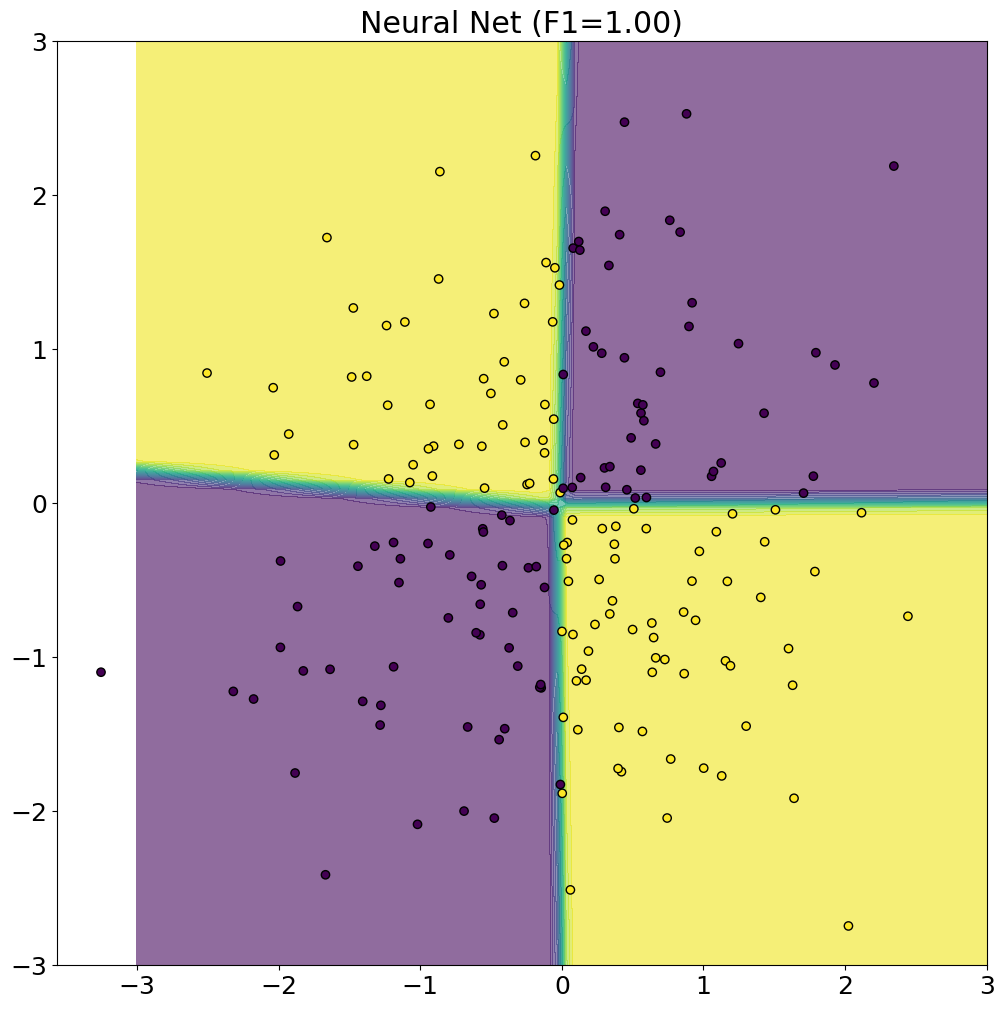

In [94]:

# =========================
# PLOT DECISION BOUNDARY
# =========================
def plot_boundary(model, title):
    xx, yy = torch.meshgrid(
        torch.linspace(-3, 3, 100),
        torch.linspace(-3, 3, 100),
        indexing='ij'
    )

    grid = torch.cat([xx.reshape(-1,1), yy.reshape(-1,1)], dim=1)

    with torch.no_grad():
        zz = model(grid).reshape(100, 100)

    plt.contourf(xx.numpy(), yy.numpy(), zz.numpy(), levels=20, alpha=0.6)
    plt.scatter(X[:,0], X[:,1], c=y.squeeze(), edgecolors='k')
    plt.title(title)
    plt.show()


plot_boundary(log_model, f"Logistic (F1={f1_log:.2f})")
plot_boundary(nn_model,  f"Neural Net (F1={f1_nn:.2f})")


In [ ]:

# =========================
# FIX COLAB NOTEBOOK FOR GITHUB
# =========================
import json

# change this to your notebook filename
fname = "XOR_2026.ipynb"

with open(fname, "r", encoding="utf-8") as f:
    nb = json.load(f)

# remove problematic widget metadata
if "widgets" in nb.get("metadata", {}):
    del nb["metadata"]["widgets"]

# also clean per-cell metadata (just in case)
for cell in nb.get("cells", []):
    if "metadata" in cell and "widgets" in cell["metadata"]:
        del cell["metadata"]["widgets"]

with open(fname, "w", encoding="utf-8") as f:
    json.dump(nb, f, indent=1)

print("Notebook cleaned. Reload it and push to GitHub.")
